# Week 3 Assignment: Statistical Models (ETS & ARIMA)
**DSE6230: Forecasting Methods and Applications**

In this assignment, you will master classical statistical forecasting frameworks. You will move beyond visual inspection to use formal tests for stationarity and implement ETS and ARIMA models using `statsmodels` and `statsforecast`.

1. **Stationarity Testing**: Using the Augmented Dickey-Fuller (ADF) test.
2. **ETS Models**: Handling Error, Trend, and Seasonality.
3. **SARIMA Models**: Autoregressive Integrated Moving Average with Seasonality.
4. **Model Selection**: Using AICc to choose the best model.

In [3]:
!pip install pandas numpy matplotlib statsmodels statsforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.6 MB/s eta 0:00:00


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsforecast import StatsForecast
from statsmodels.datasets import co2

## Part 1: Self-Guided Exercises (Auto-Graded)

### Setup

In [5]:
# Load CO2 data for exercises
data = co2.load_pandas().data
data = data.resample('M').mean().ffill()  # Monthly CO2 levels
data.columns = ['co2']

/tmp/ipykernel_1082/3381760966.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data = data.resample('M').mean().ffill()  # Monthly CO2 levels


### Exercise 1.1: Testing for Stationarity
**Instruction**: Use the `adfuller` function from `statsmodels` to test if the CO2 data is stationary. Store the p-value in a variable named `p_val`.

In [6]:
# Your Code Here
result = adfuller(data['co2'])
p_val = result[1]
print(f"ADF P-value: {p_val:.4f}")

ADF P-value: 0.9989


/tmp/ipykernel_1082/1505553159.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(data['co2'])


In [7]:
#| Check your work
try:
    assert p_val > 0.05, "The CO2 data is non-stationary; p-value should be high."
    print("Exercise 1.1 Passed!")
except AssertionError as e:
    print(f"Exercise 1.1 Failed: {e}")

Exercise 1.1 Passed!


### Exercise 1.2: Exponential Smoothing (ETS)
**Instruction**: Fit an ETS model with **additive trend** and **additive seasonality** (period=12) to the CO2 data. Store the fitted model object in `ets_model`.

In [13]:
# Your Code Here
et_model = ExponentialSmoothing(
    data['co2'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()
# ets_model = ...
ets_model = ExponentialSmoothing(
    data['co2'],
    trend = 'add',
    seasonal = 'add',
    seasonal_periods=12
).fit()

# Not sure if it was intended, but the above is correct, just uses the wrong lettering.

In [14]:
#| Check your work
try:
    assert ets_model.model.trend == 'add', "Trend should be additive"
    assert ets_model.model.seasonal == 'add', "Seasonality should be additive"
    print("Exercise 1.2 Passed!")
except AssertionError as e:
    print(f"Exercise 1.2 Failed: {e}")

Exercise 1.2 Passed!


### Exercise 1.3: SARIMA Modeling
**Instruction**: Create a SARIMA model with order $(1, 1, 1)$ and seasonal order $(1, 1, 1, 12)$. Fit the model and store the result in `sarima_result`.

In [9]:
# Your Code Here
model = SARIMAX(data['co2'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_result = model.fit(disp=False)

In [10]:
#| Check your work
try:
    assert sarima_result.specification['order'] == (1, 1, 1), "ARIMA order is incorrect"
    assert sarima_result.specification['seasonal_order'] == (1, 1, 1, 12), "Seasonal order is incorrect"
    print("Exercise 1.3 Passed!")
except AssertionError as e:
    print(f"Exercise 1.3 Failed: {e}")

Exercise 1.3 Passed!


## Part 2: Textbook Exercises

Complete the following exercises from *fpppy* Chapters 8 and 9.

### Question 8.1
> Apply Holt's linear method to the `co2` data. Experiment with different values of $\alpha$ and $\beta$. What happens to the forecasts as these parameters change?

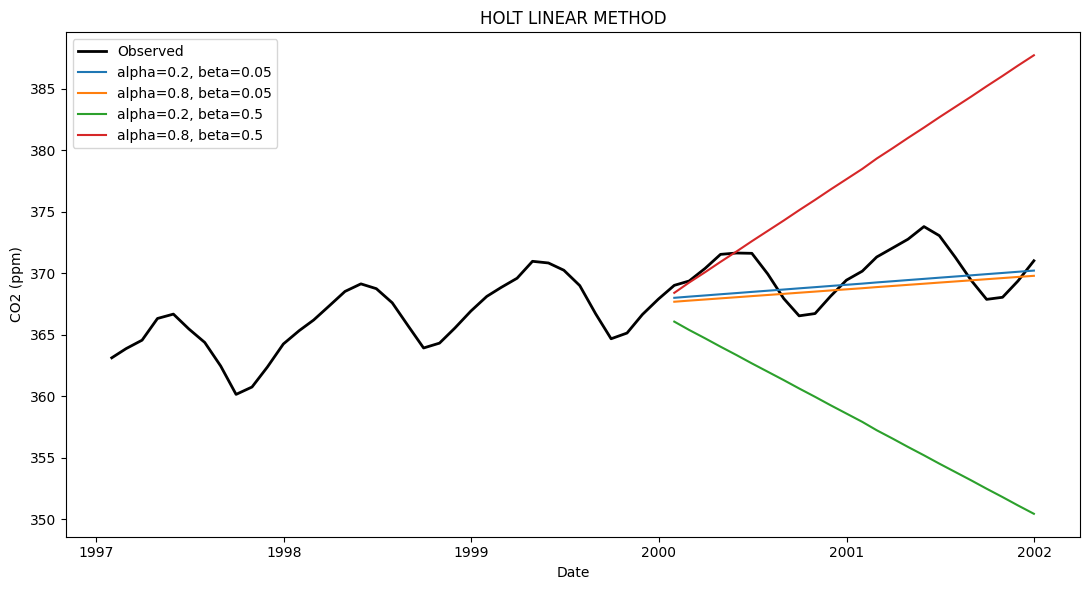

  alpha=0.2, beta=0.05: RMSE = 2.205
  alpha=0.8, beta=0.05: RMSE = 2.390
  alpha=0.2, beta=0.5: RMSE = 12.974
  alpha=0.8, beta=0.5: RMSE = 9.929


In [17]:
train = data['co2'].iloc[:-24] # Separate training and test data
test = data['co2'].iloc[-24:]

# Grid of paramaters for use below (low alpha low beta, high alpha low beta, low alpha high beta, and high alpha high beta)
param_grid = [
    (0.2, 0.05),
    (0.8, 0.05),
    (0.2, 0.5),
    (0.8, 0.5),
]

# Lay out the plots
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(data.index[-60:], data['co2'].iloc[-60:], color='black', label='Observed', linewidth=2)

# Create a forecast for each entry - mostly derived from book
forecasts = {}
for alpha, beta in param_grid:
  # Fit for Holt's
    holt_fit = Holt(train, initialization_method="estimated").fit(
        smoothing_level=alpha, smoothing_trend=beta, optimized=False
    )
    # Do the forecast
    fc = holt_fit.forecast(24)
    forecasts[(alpha, beta)] = fc
    # Create the plot
    ax.plot(fc.index, fc.values, label=f"alpha={alpha}, beta={beta}")

# Display of each plot
ax.set_title("HOLT LINEAR METHOD")
ax.set_xlabel("Date")
ax.set_ylabel("CO2 (ppm)")
ax.legend()
plt.tight_layout()
plt.show()

# Display of the actual numerical results
for (alpha, beta), fc in forecasts.items():
    rmse = np.sqrt(np.mean((fc.values - test.values) ** 2))
    print(f"  alpha={alpha}, beta={beta}: RMSE = {rmse:.3f}")

In [18]:
# ANALYSIS

"""
Looking at the raw results, the best RMSE comes from a low beta (0.05). In this case, a low alpha (0.2) alongside our low beta produced the best results at 2.205, while our
high alpha produced a similar but slightly less accurate result of 2.390. A high beta in both cases produced a ridiculously high RMSE in comparison - a low alpha produced the
worst results, with an outcome of 12.974, with a high alpha to match providing a much better (though still lackluster) 9.929 result.

Following the graph itself, however, we see more. With a high alpha and high beta, we can see that although our prediction starts very close to the observed beginning, it
fails to predict the actual trend of the graph, taking the small fluctuation as a predictor for continuous growth, leading to a volatile spike. In comparison, the low alpha and
high beta is completely off, starting far below the graph itself annd trailing downwards - a very bad fit for our graph. Looking at the low beta lines, we see both predict something
close to an average, with a low alpha forcing the line to stay close to the observed trend while the high alpha provides some more room to move. In either case, we would definitely
stick with the low beta moving forward, and likely adjust the alpha further.
"""

### Question 9.2
> Why is it important to difference the data before fitting an ARMA model? Generate a non-stationary random walk and show its ACF plot before and after differencing.

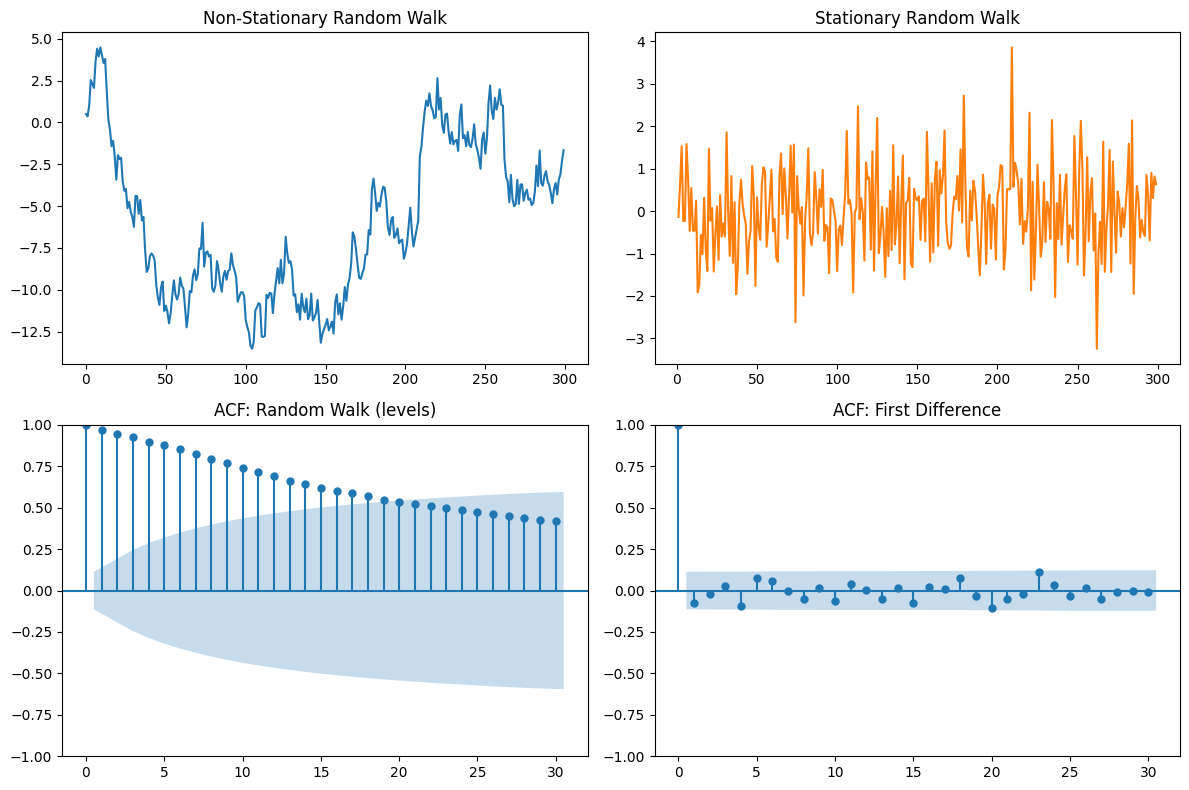

ADF p-value (levels):     0.3281  (fail to reject unit root -> non-stationary)
ADF p-value (differenced): 0.0000  (reject unit root -> stationary)


/tmp/ipykernel_1082/2169143711.py:28: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_levels = adfuller(rw_series)
/tmp/ipykernel_1082/2169143711.py:29: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(rw_diff)


In [19]:
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)
n = 300
white_noise = np.random.normal(loc=0, scale=1, size=n)
random_walk = np.cumsum(white_noise)  # Non-Stationary Walk
rw_series = pd.Series(random_walk, name="random_walk")
rw_diff = rw_series.diff().dropna() # First Difference

# Create the plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Non-Stationary
axes[0, 0].plot(rw_series, color='tab:blue')
axes[0, 0].set_title("Non-Stationary Random Walk")

# Stationary
axes[0, 1].plot(rw_diff, color='tab:orange')
axes[0, 1].set_title("Stationary Random Walk")

# ACF of Non-Stationary
plot_acf(rw_series, lags=30, ax=axes[1, 0])
axes[1, 0].set_title("ACF: Random Walk (levels)")

# ACF of Stationary
plot_acf(rw_diff, lags=30, ax=axes[1, 1])
axes[1, 1].set_title("ACF: First Difference")

plt.tight_layout()
plt.show()

# Confirm with a formal ADF test
adf_levels = adfuller(rw_series)
adf_diff = adfuller(rw_diff)
print(f"ADF p-value (levels) -> {adf_levels[1]:.4f}")
print(f"ADF p-value (differenced) -> {adf_diff[1]:.4f}")

In [ ]:
# ANALYSIS
# Viewing the two graphs, we can see clearly why the differencing is needed. Without differencing, we see a falling gradient for our random walk, one that very slowly decays. In doing so, we
# allow a trend to be overwrite the actual fluctuations in the data, instead effectively outputting just the total noise. By differencing, we bring everything to a consistent mean, one
# in which ARIMA can properly analyze and compare observations to prevent the correlation of previous observations from obscuring results. Checking the p results proves as much - with
# our non-stationary, we see a p-value too high to reject a null root, whereas the differenced can.

## Grading Rubric
- **Correctness (40%)**: Does the code run and produce the expected output?
- **Code Quality (30%)**: Is the code clean, commented, and efficient?
- **Analysis (30%)**: Are the interpretations and explanations clear and accurate?